# 2. Phân tích phân phối xác suất

## Mục tiêu phân tích và lựa chọn biến
Phân tích hai biến quan trọng: **strength** (cường độ chịu nén, MPa), biến mục tiêu; và **w_c** (nước/xi măng, không đơn vị), chỉ tiêu cấp phối có ý nghĩa kỹ thuật. Tỷ lệ này không bao gồm slag và fly ash ở mẫu số, vì vậy không đồng nhất với tỷ lệ nước/chất kết dính.

**Strength** được chọn vì phản ánh trực tiếp kết quả chịu lực của mẫu bê tông. Phân phối của biến này cho biết mức cường độ tập trung, độ biến thiên và đặc điểm của các mẫu ở hai đuôi.

**w_c = water / cement** được chọn vì cùng một lượng nước nhưng lượng xi măng khác nhau sẽ tạo tỷ lệ cấp phối khác nhau. Đây là biến dẫn xuất đã có từ EDA. Hai biến bổ sung cho nhau: strength mô tả kết quả thí nghiệm, còn w_c mô tả một đặc điểm cấp phối liên quan đến kết quả. Việc lựa chọn dựa trên vai trò trong bài toán, không dựa vào khả năng khớp một phân phối cụ thể.

Mục tiêu là xác định đặc điểm phân phối của từng biến, so sánh các họ phân phối ứng viên và đánh giá mức độ phù hợp bằng thống kê cùng biểu đồ. Phân tích sử dụng toàn bộ quan sát sau EDA để phản ánh phân phối thực nghiệm của bộ dữ liệu.

In [1]:
from pathlib import Path
import hashlib, json, platform
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data/processed/cleaned.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Mở notebook trong repository hoặc thư mục notebooks.')
DATA = ROOT/'data/processed/cleaned.csv'
HASH = hashlib.sha256(DATA.read_bytes()).hexdigest()
df = pd.read_csv(DATA)
VARIABLES = {'strength': 'Cường độ chịu nén (MPa)', 'w_c': 'Tỷ lệ nước/xi măng'}
for v in VARIABLES:
    assert pd.api.types.is_numeric_dtype(df[v])
    assert np.isfinite(df[v]).all() and (df[v] > 0).all()
assert np.allclose(df.w_c, df.water/df.cement)
FIG = ROOT/'figures/distribution_analysis'
TAB = ROOT/'tables/distribution_analysis'
REPORT = ROOT/'report/distribution_analysis'
for p in [FIG, TAB, REPORT]: p.mkdir(parents=True, exist_ok=True)
print(f'Số quan sát: {len(df):,}; số biến trong dữ liệu sau EDA: {df.shape[1]}')
display(df[list(VARIABLES)].head())

Số quan sát: 1,005; số biến trong dữ liệu sau EDA: 17


,strength,w_c
0,79.986111,0.300000
1,61.887366,0.300000
2,40.269535,0.685714
3,41.052780,0.685714
4,44.296075,0.966767


In [2]:
# Đối chiếu vai trò của tỷ lệ nước/xi măng với lượng nước riêng lẻ.
relevance = pd.DataFrame([
    {'variable': v, 'spearman_with_strength': stats.spearmanr(df[v], df.strength).statistic}
    for v in ['water', 'w_c']
])
display(relevance.round(4))
rho_water, rho_wc = relevance.spearman_with_strength.to_numpy()
selection_text = (
    f'Trong mẫu quan sát, tương quan Spearman của w_c với strength là {rho_wc:.4f}, '
    f'còn water với strength là {rho_water:.4f}. '
    'Đây là căn cứ thực nghiệm bổ sung cho lựa chọn w_c. '
    'Tương quan mô tả liên hệ trong mẫu, không chứng minh tác động nhân quả.'
)
display(Markdown(selection_text))

,variable,spearman_with_strength
0,water,-0.2842
1,w_c,-0.5038


Trong mẫu quan sát, tương quan Spearman của w_c với strength là -0.5038, còn water với strength là -0.2842. Đây là căn cứ thực nghiệm bổ sung cho lựa chọn w_c. Tương quan mô tả liên hệ trong mẫu, không chứng minh tác động nhân quả.

## 2.1. Kiểm tra và mô tả dữ liệu
EDA đã loại 25 dòng trùng từ 1.030 dòng, giữ 1.005 dòng và bổ sung các biến/cờ. Ta kiểm tra lại kiểu số, tính hữu hạn, miền dương và công thức w_c; không điền khuyết, loại ngoại lai hay biến đổi dữ liệu.

Mean và median cho biết vị trí trung tâm; độ lệch chuẩn và IQR phản ánh độ phân tán; skewness đo bất đối xứng; excess kurtosis so sánh hình dạng với chuẩn (chuẩn có giá trị 0). Hai chỉ số hình dạng không đủ để xác nhận một họ phân phối.

In [3]:
summary = pd.DataFrame([{ 'variable': v, 'n': len(df), 'unique': df[v].nunique(),
    'mean': df[v].mean(), 'median': df[v].median(), 'std': df[v].std(ddof=1),
    'min': df[v].min(), 'q1': df[v].quantile(.25), 'q3': df[v].quantile(.75),
    'max': df[v].max(), 'skewness': stats.skew(df[v], bias=False),
    'excess_kurtosis': stats.kurtosis(df[v], bias=False)} for v in VARIABLES])
summary.to_csv(TAB/'descriptive.csv', index=False, encoding='utf-8-sig')
display(summary.round(4))

,variable,n,unique,mean,median,std,min,q1,q3,max,skewness,excess_kurtosis
0,strength,1005,938,35.2503,33.7981,16.2848,2.3318,23.5235,44.8683,82.5992,0.3957,-0.3054
1,w_c,1005,382,0.7562,0.6895,0.3135,0.2669,0.5475,0.9375,1.8824,0.9404,0.7175


## 2.2. Các phân phối ứng viên và phương pháp
- **Chuẩn**: mốc tham chiếu đối xứng, hai tham số μ, σ. Miền thực có thể cấp xác suất cho giá trị âm; ta báo cáo xác suất này để đánh giá ý nghĩa vật lý.
- **Lognormal**: biến dương với log tự nhiên có phân phối chuẩn; phù hợp để thử hình dạng lệch phải. Tham số SciPy s là độ lệch chuẩn của log(X), scale = exp(mean(log(X))).
- **Gamma**: biến dương, linh hoạt từ lệch phải đến gần đối xứng; a là shape và scale là θ, mean = aθ.
- **Exponential**: biến dương có một tham số scale, mean = scale và độ lệch chuẩn = mean; dùng như mô hình đơn giản để đối chiếu. Đây không phải giả định về cơ chế tuổi thọ của bê tông.

Lognormal, gamma và exponential cố định **loc = 0** theo gốc vật lý; không dịch theo giá trị nhỏ nhất của mẫu. Chuẩn ước lượng cả loc và scale. Poisson không phù hợp vì hai biến không phải số đếm sự kiện nguyên. Age có các mốc lịch thí nghiệm; các thành phần có số 0 cấu trúc cũng không được ép vào các mô hình liên tục dương này.

Ước lượng tham số bằng cực đại hợp lý (MLE): chọn bộ tham số làm tổng log mật độ tại các quan sát lớn nhất, logL = Σ log f(xᵢ; θ). Với chuẩn, μ là trung bình mẫu và σ là độ lệch chuẩn với mẫu số n; đây là ước lượng MLE, khác độ lệch chuẩn mô tả dùng mẫu số n−1. Với lognormal có loc=0, s và log(scale) lần lượt là độ lệch chuẩn MLE và trung bình của log(X). Với exponential có loc=0, scale bằng trung bình mẫu. Tham số gamma được giải bằng phép fit cực đại hợp lý của SciPy.

AIC = 2k − 2logL, BIC = k log(n) − 2logL; n là số quan sát và k chỉ đếm tham số tự do. Hai tiêu chí cân bằng mức khớp dữ liệu với độ phức tạp của mô hình. Giá trị thấp hơn tốt hơn **trong cùng một biến và cùng tập quan sát**, không chứng minh mô hình đúng.

Thống kê KS là khoảng cách lớn nhất giữa CDF thực nghiệm và CDF fitted. Vì tham số được ước lượng từ mẫu, không dùng p-value KS tiêu chuẩn cho tham số đã biết. Thay vào đó: fit mẫu thật → sinh mẫu từ mô hình fitted → **fit lại từng mẫu** → tính KS → p = (1 + số KS mô phỏng ≥ KS thật)/(B + 1). Dùng B = 1.999 và seed cố định; độ phân giải p là 0,0005. Khoảng tin cậy nhị thức cho p Monte Carlo giúp thể hiện sai số mô phỏng. H0: mẫu đến từ một thành viên của họ đang xét; α = 0,05. p nhỏ bác bỏ H0; p lớn chỉ là chưa đủ bằng chứng bác bỏ.

Kiểm định giả định quan sát độc lập cùng phân phối; dữ liệu thí nghiệm có thể chứa cấp phối/tuổi liên quan mà không có mã nhóm để hiệu chỉnh, nên diễn giải p có điều kiện trên giả định này. Làm tròn và các giá trị lặp cũng ảnh hưởng kiểm định liên tục. Kết luận kết hợp p, AIC/BIC và đồ thị; không dùng p như xác suất H0 đúng.

In [4]:
DISTS = {'normal': stats.norm, 'lognormal': stats.lognorm, 'gamma': stats.gamma, 'exponential': stats.expon}
B = 1999
SEED = 20261009
def fit(name, x):
    return DISTS[name].fit(x) if name == 'normal' else DISTS[name].fit(x, floc=0)
def ks_distance(x, name, pars):
    z = np.sort(x)
    f = DISTS[name].cdf(z, *pars)
    n = len(z)
    return max(np.max(np.arange(1, n+1)/n-f), np.max(f-np.arange(n)/n))
rows, fitted = [], {}
for vi, v in enumerate(VARIABLES):
    x = df[v].to_numpy()
    for di, name in enumerate(DISTS):
        pars = fit(name, x)
        fitted[v, name] = pars
        ll = DISTS[name].logpdf(x, *pars).sum()
        assert np.isfinite(ll)
        k = 1 if name == 'exponential' else 2
        observed = ks_distance(x, name, pars)
        rng = np.random.default_rng(SEED + 100*vi + di)
        null = np.empty(B)
        for i in range(B):
            simulated = DISTS[name].rvs(*pars, size=len(x), random_state=rng)
            null[i] = ks_distance(simulated, name, fit(name, simulated))
        exceed = int((null >= observed).sum())
        p = (exceed+1)/(B+1)
        ci = stats.binomtest(exceed, B).proportion_ci(confidence_level=.95)
        rows.append(dict(variable=v, distribution=name, parameters=json.dumps([float(a) for a in pars]),
            k=k, log_likelihood=ll, AIC=2*k-2*ll, BIC=k*np.log(len(x))-2*ll,
            KS=observed, p_bootstrap=p, mc_ci_low=ci.low, mc_ci_high=ci.high,
            negative_mass=DISTS[name].cdf(0, *pars)))
        print(v, name, 'p =', p)
results = pd.DataFrame(rows)
results['delta_AIC'] = results.AIC-results.groupby('variable').AIC.transform('min')
results['reject_005'] = results.p_bootstrap < .05
results.to_csv(TAB/'distribution_fits.csv', index=False, encoding='utf-8-sig')
display(results.round(5))

strength normal p = 0.0005


strength lognormal p = 0.0005


strength gamma p = 0.0005


strength exponential p = 0.0005


w_c normal p = 0.0005


w_c lognormal p = 0.0015


w_c gamma p = 0.0005


w_c exponential p = 0.0005


,variable,distribution,parameters,k,log_likelihood,AIC,BIC,KS,p_bootstrap,mc_ci_low,mc_ci_high,negative_mass,delta_AIC,reject_005
0,strength,normal,"[35.25027287623584, 16.276703743195682]",2,-4229.71677,8463.43354,8473.25902,0.03867,0.0005,0.00000,0.00184,0.01517,27.44242,True
1,strength,lognormal,"[0.5474955729642654, 0.0, 30.994410711943956]",2,-4271.59624,8547.19248,8557.01797,0.09141,0.0005,0.00000,0.00184,0.00000,111.20136,True
2,strength,gamma,"[4.045176496767865, 0.0, 8.714149532016997]",2,-4215.99556,8435.99112,8445.81661,0.05791,0.0005,0.00000,0.00184,0.00000,0.00000,True
3,strength,exponential,"[0.0, 35.25027287623584]",1,-4585.28564,9172.57127,9177.48402,0.24553,0.0005,0.00000,0.00184,0.00000,736.58015,True
4,w_c,normal,"[0.7562228775055905, 0.3133681948156608]",2,-259.85491,523.70981,533.53530,0.10816,0.0005,0.00000,0.00184,0.00791,204.34896,True
5,w_c,lognormal,"[0.4063982000733731, 0.0, 0.6965464632628198]",2,-157.68042,319.36085,329.18633,0.04029,0.0015,0.00012,0.00361,0.00000,0.00000,True
6,w_c,gamma,"[6.244536728291594, 0.0, 0.12110151808050636]",2,-168.94968,341.89935,351.72484,0.05747,0.0005,0.00000,0.00184,0.00000,22.53851,True
7,w_c,exponential,"[0.0, 0.7562228775055905]",1,-724.18377,1450.36754,1455.28028,0.33985,0.0005,0.00000,0.00184,0.00000,1131.00669,True


## 2.3. Biểu đồ: đọc gì và tại sao?
Histogram dùng mật độ (diện tích tổng bằng 1) để cùng thang với PDF. Quy tắc Freedman–Diaconis chọn độ rộng bin bằng 2 × IQR × n^(−1/3), hạn chế chọn bin tùy tiện. KDE là ước lượng mật độ phi tham số, dùng bandwidth Scott; so sánh thêm 0,7 và 1,3 lần bandwidth để kiểm tra đỉnh có phụ thuộc làm trơn. KDE Gaussian có thể tràn qua gốc 0; chỉ xem đây là công cụ mô tả.

PDF fitted thể hiện mức mô hình khớp vùng trung tâm và đuôi. Q-Q đặt phân vị lý thuyết trên trục ngang và phân vị mẫu trên trục dọc: sát đường y=x thì phù hợp; cong có hệ thống cho thấy sai khác hình dạng, lệch ở hai đầu phản ánh khác biệt đuôi. Dùng plotting position (i−0,5)/n để tránh phân vị vô hạn. ECDF và CDF fitted giúp đọc thêm sai lệch xác suất tích lũy; không chỉ dựa vào histogram.

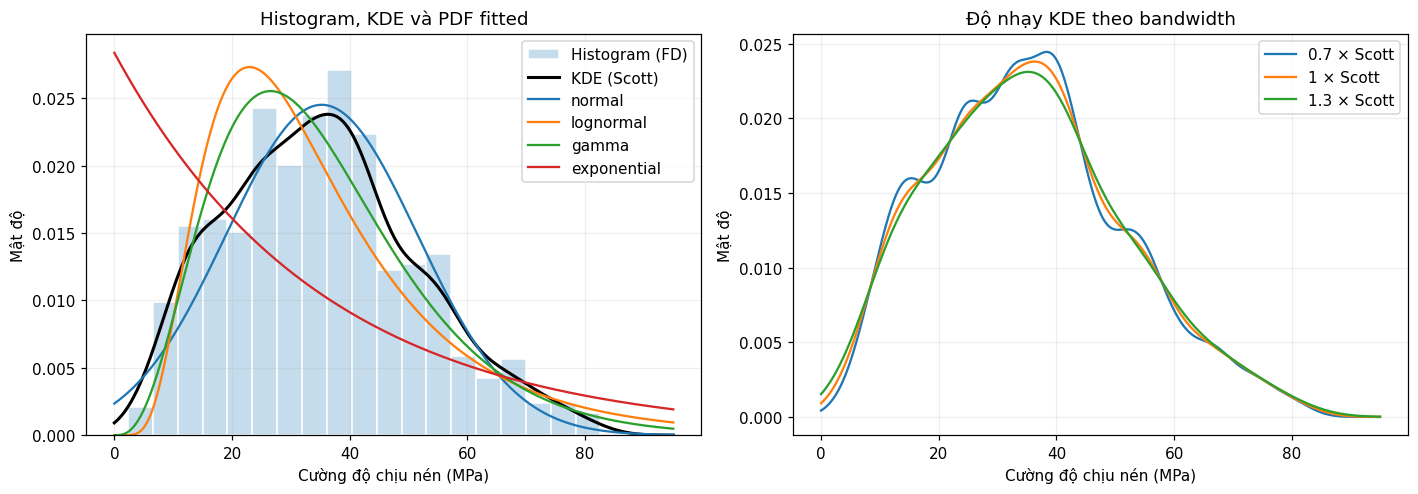

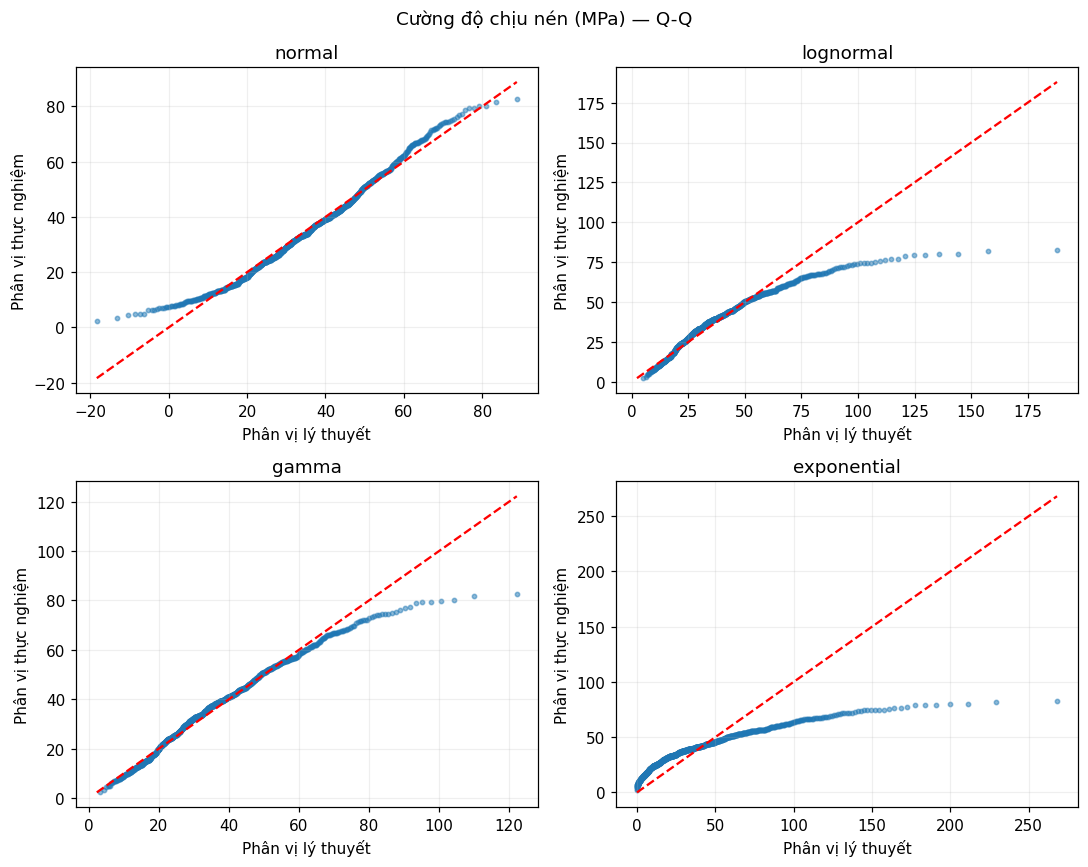

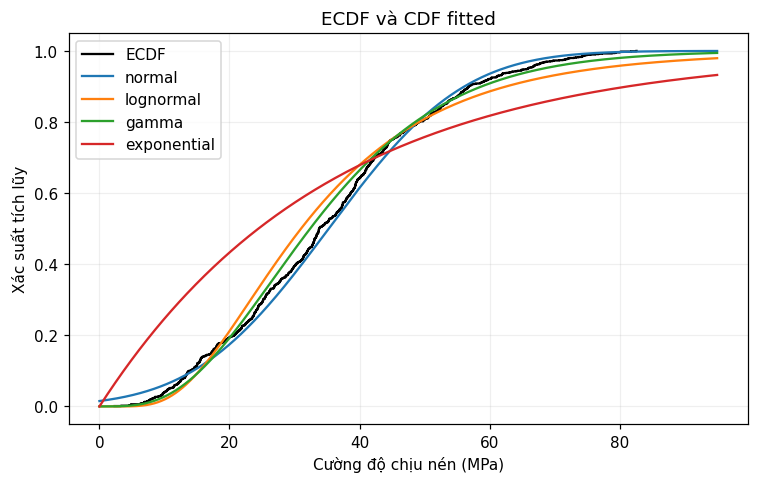

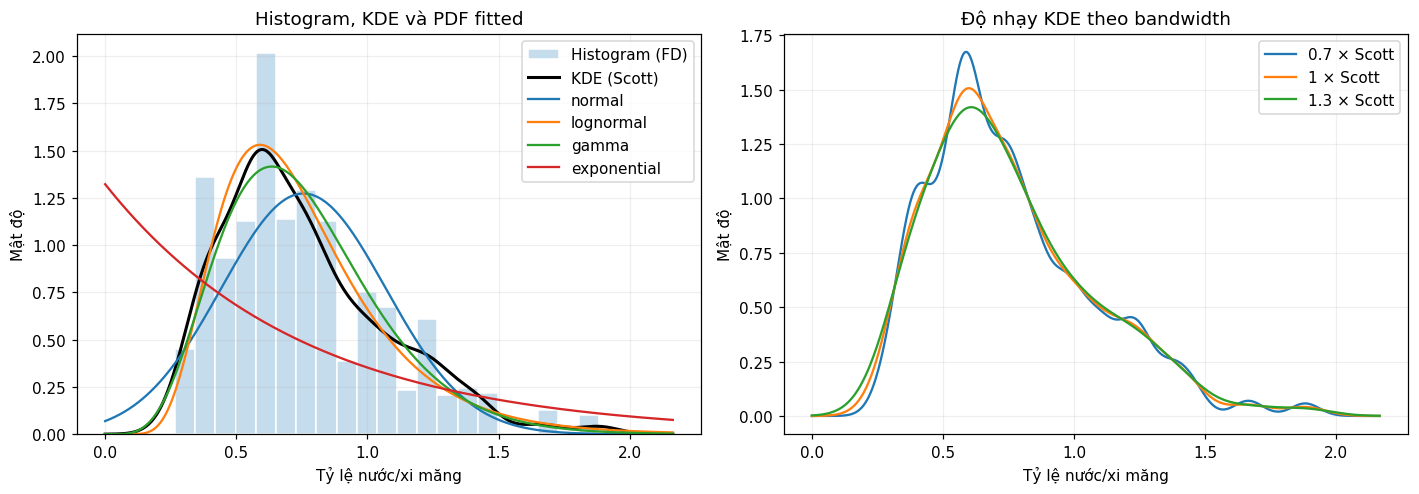

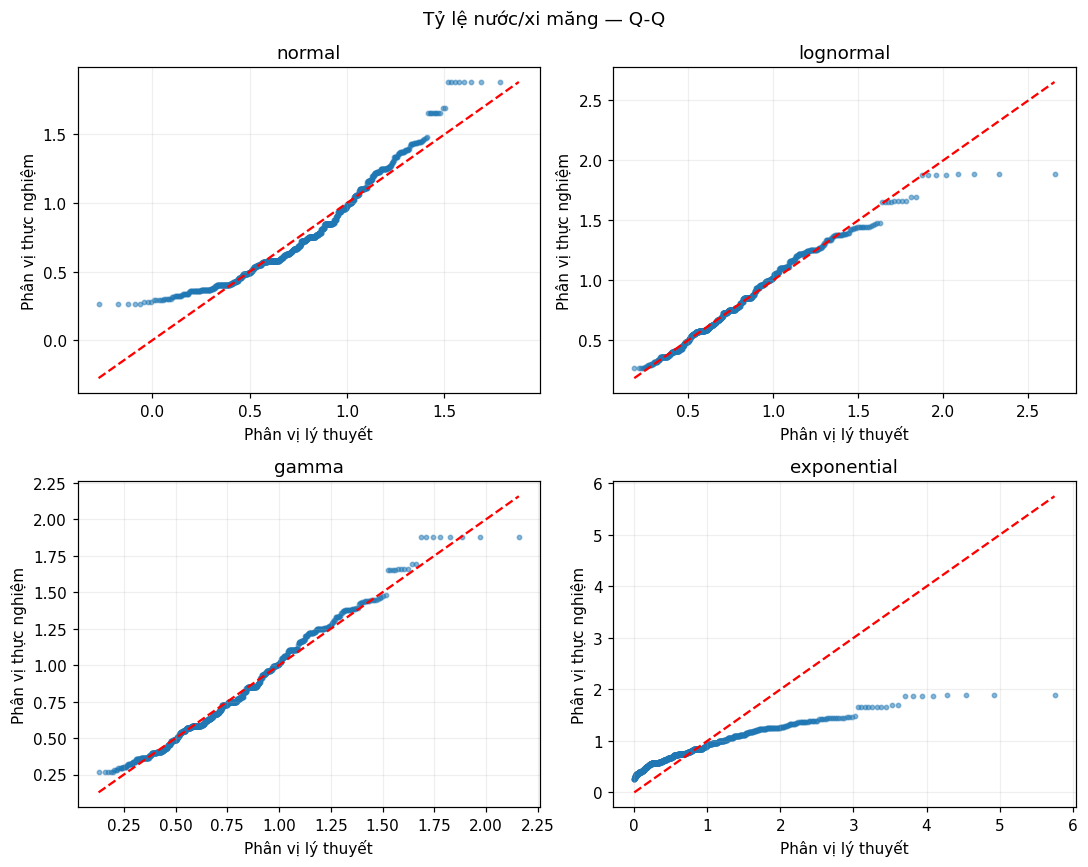

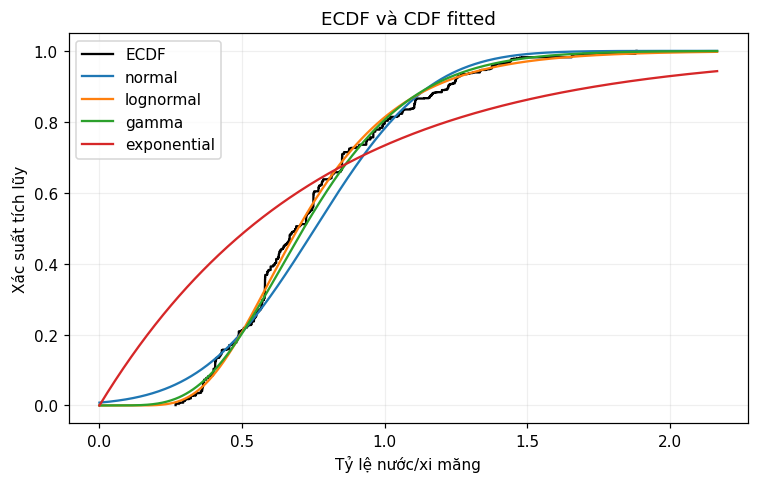

In [5]:
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})
for v, label in VARIABLES.items():
    x = df[v].to_numpy()
    grid = np.linspace(0, x.max()*1.15, 700)
    kde = stats.gaussian_kde(x)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    ax[0].hist(x, bins='fd', density=True, color='#c5dced', edgecolor='white', label='Histogram (FD)')
    ax[0].plot(grid, kde(grid), color='black', lw=2, label='KDE (Scott)')
    for name in DISTS:
        ax[0].plot(grid, DISTS[name].pdf(grid, *fitted[v, name]), label=name)
    for factor in [.7, 1, 1.3]:
        ax[1].plot(grid, stats.gaussian_kde(x, bw_method=kde.factor*factor)(grid), label=f'{factor} × Scott')
    for a in ax:
        a.set(xlabel=label, ylabel='Mật độ'); a.legend(); a.grid(alpha=.2)
    ax[0].set_title('Histogram, KDE và PDF fitted')
    ax[1].set_title('Độ nhạy KDE theo bandwidth')
    fig.tight_layout(); fig.savefig(FIG/f'{v}_hist_kde_pdf.png', dpi=180); plt.show(); plt.close(fig)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    prob = (np.arange(1, len(x)+1)-.5)/len(x)
    for a, name in zip(axes.flat, DISTS):
        theoretical = DISTS[name].ppf(prob, *fitted[v, name])
        a.scatter(theoretical, np.sort(x), s=8, alpha=.5)
        lo, hi = min(theoretical.min(), x.min()), max(theoretical.max(), x.max())
        a.plot([lo, hi], [lo, hi], 'r--')
        a.set(title=name, xlabel='Phân vị lý thuyết', ylabel='Phân vị thực nghiệm'); a.grid(alpha=.2)
    fig.suptitle(label+' — Q-Q'); fig.tight_layout()
    fig.savefig(FIG/f'{v}_qq.png', dpi=180); plt.show(); plt.close(fig)
    fig, a = plt.subplots(figsize=(7, 4.5))
    a.step(np.sort(x), np.arange(1,len(x)+1)/len(x), where='post', color='black', label='ECDF')
    for name in DISTS: a.plot(grid, DISTS[name].cdf(grid,*fitted[v,name]), label=name)
    a.set(xlabel=label, ylabel='Xác suất tích lũy', title='ECDF và CDF fitted'); a.legend(); a.grid(alpha=.2)
    fig.tight_layout(); fig.savefig(FIG/f'{v}_ecdf.png', dpi=180); plt.show(); plt.close(fig)

## 2.4. So sánh phân vị và bối cảnh tuổi mẫu
Sai số phân vị fitted − thực nghiệm tại 1%, 5%, 50%, 95%, 99% lượng hóa lệch đuôi trên đơn vị gốc. Xem strength theo nhóm tuổi đã có từ EDA để giải thích vì sao phân phối gộp có thể khác một họ đơn giản. Đây là mô tả có điều kiện, không phải bằng chứng nhân quả hay kiểm định riêng cho từng nhóm.

In [6]:
qrows = []
for v in VARIABLES:
    for name in DISTS:
        for q in [.01,.05,.5,.95,.99]:
            empirical = df[v].quantile(q)
            model = DISTS[name].ppf(q,*fitted[v,name])
            qrows.append(dict(variable=v, distribution=name, probability=q, empirical=empirical, fitted=model, error=model-empirical))
quantiles = pd.DataFrame(qrows)
quantiles.to_csv(TAB/'quantile_errors.csv', index=False, encoding='utf-8-sig')
display(quantiles.round(4))
groups = df.groupby('age_group', observed=True).strength.agg(['count','mean','median','std'])
groups.to_csv(TAB/'strength_by_age.csv', encoding='utf-8-sig')
display(groups.round(3))

,variable,distribution,probability,empirical,fitted,error
0,strength,normal,0.01,6.8845,-2.6150,-9.4995
1,strength,normal,0.05,10.7677,8.4775,-2.2902
2,strength,normal,0.50,33.7981,35.2503,1.4522
3,strength,normal,0.95,65.8651,62.0231,-3.8420
4,strength,normal,0.99,75.4772,73.1155,-2.3617
5,strength,lognormal,0.01,6.8845,8.6724,1.7879
6,strength,lognormal,0.05,10.7677,12.5945,1.8268
7,strength,lognormal,0.50,33.7981,30.9944,-2.8037
8,strength,lognormal,0.95,65.8651,76.2759,10.4108
9,strength,lognormal,0.99,75.4772,110.7718,35.2946


,count,mean,median,std
age_group,,,,
Dài ngày (>28 ngày),271,47.669,45.368,12.797
Sớm (1–7 ngày),253,21.588,17.575,12.366
Tiêu chuẩn (8–28 ngày),481,35.440,33.088,14.029


## 2.5. Tổng hợp kết quả thực nghiệm
AIC xác định mô hình có mức độ phù hợp tương đối tốt nhất trong tập ứng viên; kết luận kiểm định được xem xét riêng cho từng họ. Việc so sánh nhiều ứng viên mang tính khám phá, không suy luận bằng cách chọn p lớn nhất.

# 2. Phân tích phân phối xác suất

## Dữ liệu và mục tiêu
Phân tích 1,005 quan sát sau EDA từ `data/processed/cleaned.csv`. Giữ nguyên toàn bộ dữ liệu, kể cả các quan sát được gắn cờ ngoại lai. Chọn cường độ chịu nén strength (MPa) và tỷ lệ nước/xi măng w_c (không đơn vị). Strength là biến mục tiêu; w_c mô tả quan hệ giữa nước và xi măng trong cấp phối, không bao gồm các vật liệu bổ sung trong mẫu số.

Strength phản ánh kết quả chịu lực; phân tích phân phối giúp xác định vùng cường độ tập trung, mức biến thiên và các giá trị ở hai đuôi. w_c được chọn vì tỷ lệ kết hợp lượng nước và lượng xi măng, cung cấp thông tin cấp phối mà lượng nước riêng lẻ chưa thể hiện đầy đủ. Hai biến đại diện cho kết quả thí nghiệm và một đặc điểm cấp phối liên quan. Việc lựa chọn dựa trên ý nghĩa phân tích, không dựa vào phân phối nào dễ khớp.

Trong mẫu quan sát, tương quan Spearman của w_c với strength là -0.5038, còn water với strength là -0.2842. Đây là căn cứ thực nghiệm bổ sung cho lựa chọn w_c. Tương quan mô tả liên hệ trong mẫu, không chứng minh tác động nhân quả.

## Phương pháp
Ước lượng MLE cho chuẩn, lognormal, gamma và exponential; ba họ dương cố định loc=0. Chuẩn, lognormal và gamma có hai tham số tự do, exponential có một. So sánh AIC/BIC trong từng biến. Kiểm định KS với bootstrap tham số 1.999 lần, ước lượng lại tham số ở mỗi lần, seed 20261009; mức ý nghĩa 0,05. p-value nhỏ nhất báo cáo được là 0,0005, không có nghĩa xác suất bằng 0. Kiểm định giả định các quan sát độc lập cùng phân phối; cấu trúc cấp phối và tuổi thí nghiệm có thể ảnh hưởng mức hiệu lực của giả định này.

Histogram dùng mật độ và bin Freedman–Diaconis, KDE dùng Scott và kiểm tra độ nhạy bandwidth. PDF fitted, Q-Q theo đường y=x và ECDF được dùng bổ sung để đánh giá vùng trung tâm, đuôi và sai lệch tích lũy.

## Cường độ chịu nén (MPa)
Trung bình 35.2503, trung vị 33.7981, độ lệch chuẩn 16.2848; khoảng tứ phân vị 23.5235–44.8683, miền quan sát 2.3318–82.5992. Skewness 0.3957, excess kurtosis -0.3054. Trung bình cao hơn trung vị và skewness dương thể hiện bất đối xứng theo phía phải.

| Họ | AIC | BIC | ΔAIC | KS | p bootstrap | Kết luận ở 5% |
|---|---:|---:|---:|---:|---:|---|
| gamma | 8435.991 | 8445.817 | 0.000 | 0.0579 | 0.0005 | Bác bỏ |
| normal | 8463.434 | 8473.259 | 27.442 | 0.0387 | 0.0005 | Bác bỏ |
| lognormal | 8547.192 | 8557.018 | 111.201 | 0.0914 | 0.0005 | Bác bỏ |
| exponential | 9172.571 | 9177.484 | 736.580 | 0.2455 | 0.0005 | Bác bỏ |

gamma có AIC thấp nhất (8435.991) trong bốn họ; KS = 0.0579 nghĩa là chênh lệch tích lũy lớn nhất khoảng 5.79 điểm phần trăm. Tuy nhiên, kiểm định vẫn bác bỏ họ này; đây chỉ là mô hình xấp xỉ tốt nhất trong tập ứng viên, không phải phân phối được xác nhận.
Tham số ước lượng của các mô hình:

| Họ | Tham số |
|---|---|
| gamma | a = 4.04518; loc = 0; θ = 8.71415 |
| normal | μ = 35.25027; σ = 16.27670 |
| lognormal | s = 0.54750; loc = 0; scale = 30.99441 |
| exponential | loc = 0; scale = 35.25027 |

- gamma: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt 1.3673, -1.4061, 2.2619; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0000, 0.0018].
- normal: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt -2.2902, 1.4522, -3.8420; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0000, 0.0018].
- lognormal: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt 1.8268, -2.8037, 10.4108; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0000, 0.0018].
- exponential: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt -8.9596, -9.3645, 39.7353; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0000, 0.0018].

Histogram/KDE thể hiện một vùng đỉnh rộng khoảng 30–40 MPa và đuôi phải. Khi đổi bandwidth, các gợn nhỏ thay đổi nhưng hình dạng tổng thể ổn định. PDF chuẩn mô tả vùng đỉnh khá sát, trong khi gamma và lognormal đặt đỉnh về phía thấp hơn. Q-Q chuẩn gần đường tham chiếu ở vùng giữa, nhưng lệch ở đuôi trái vì chuẩn cho phép giá trị âm. Gamma khớp nhiều phân vị trung tâm nhưng dự báo đuôi trên dài hơn mẫu: tại 99%, mô hình cho 88,162 MPa so với 75,477 MPa thực nghiệm, lệch +12,684 MPa. Lognormal lệch mạnh hơn ở 99% (+35,295 MPa). Exponential không tái hiện được đỉnh bên trong miền dương và đánh giá quá cao đuôi trên.
Chuẩn có KS nhỏ hơn gamma (0,0387 so với 0,0579), dù AIC cao hơn 27,442. Hai tiêu chí đo các khía cạnh khác nhau: KS xét sai lệch CDF lớn nhất, còn AIC dựa trên tổng log mật độ tại các quan sát. Do đó không gọi gamma là tốt nhất trên mọi tiêu chí.

Chuẩn gán xác suất 1.517% cho giá trị ≤0, trong khi biến có miền vật lý dương.



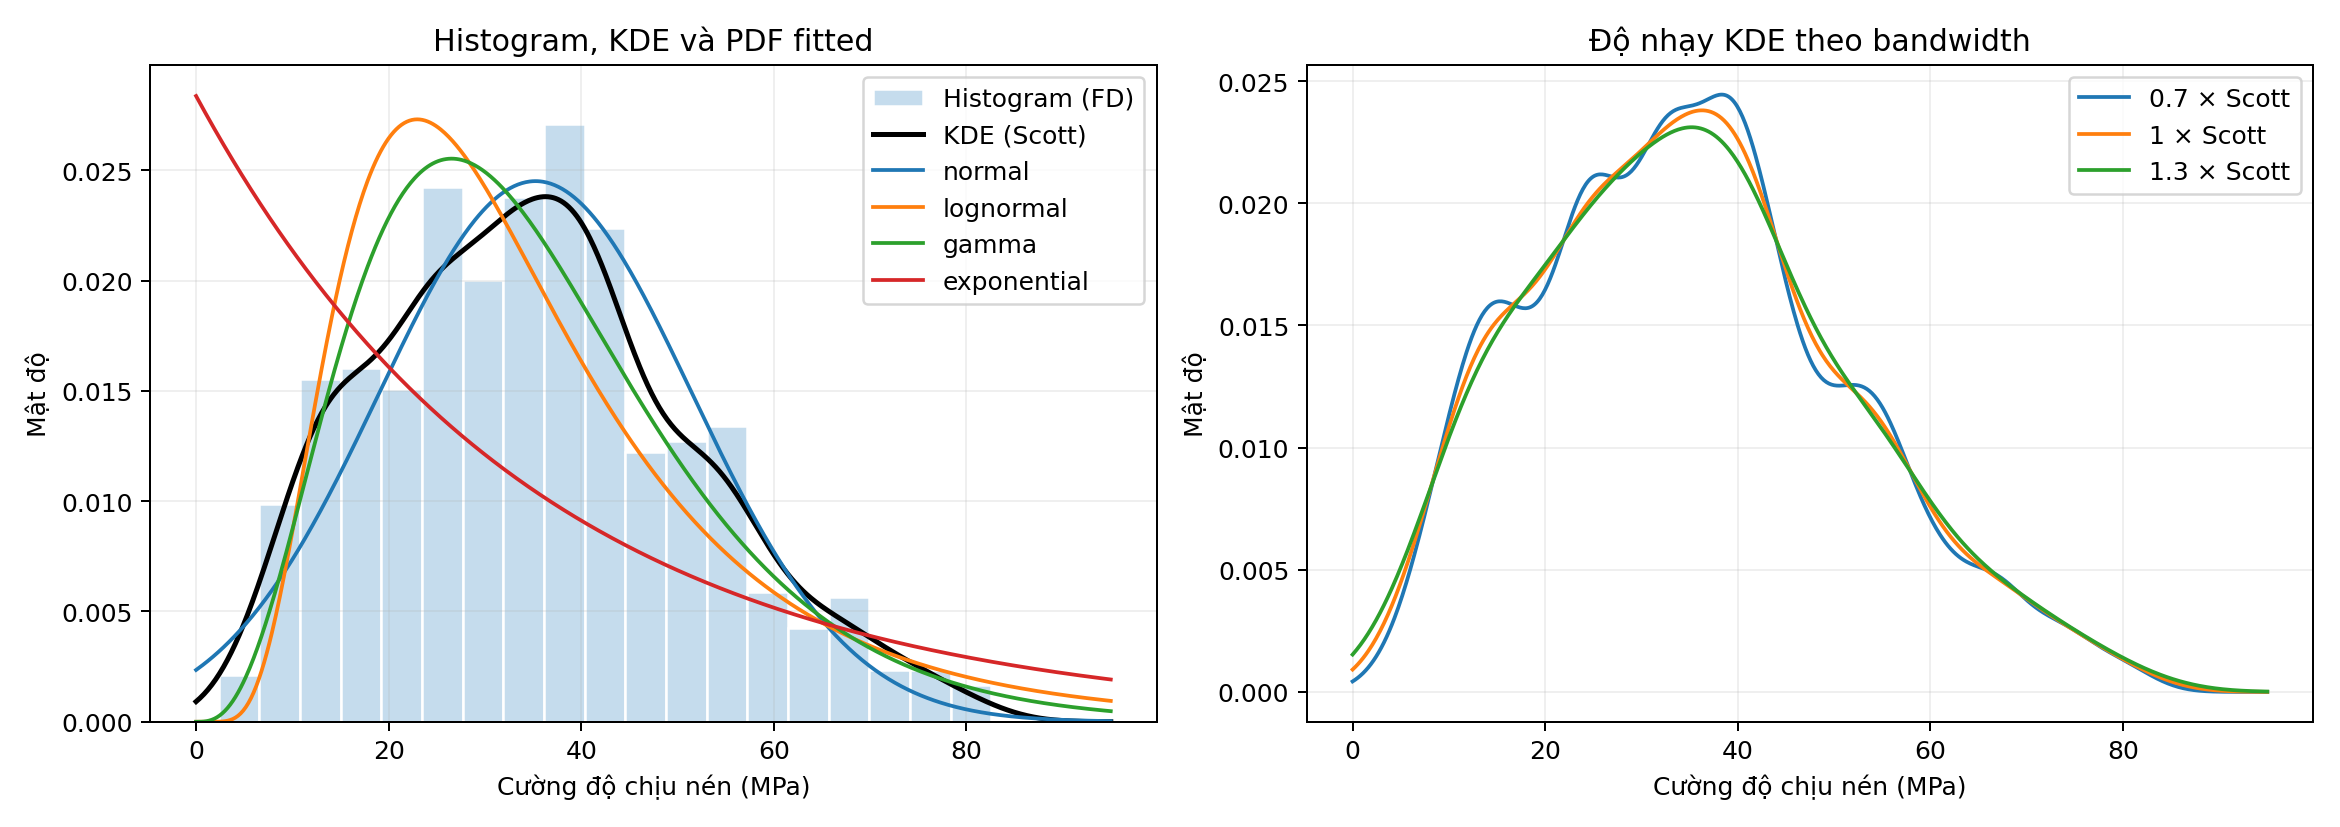

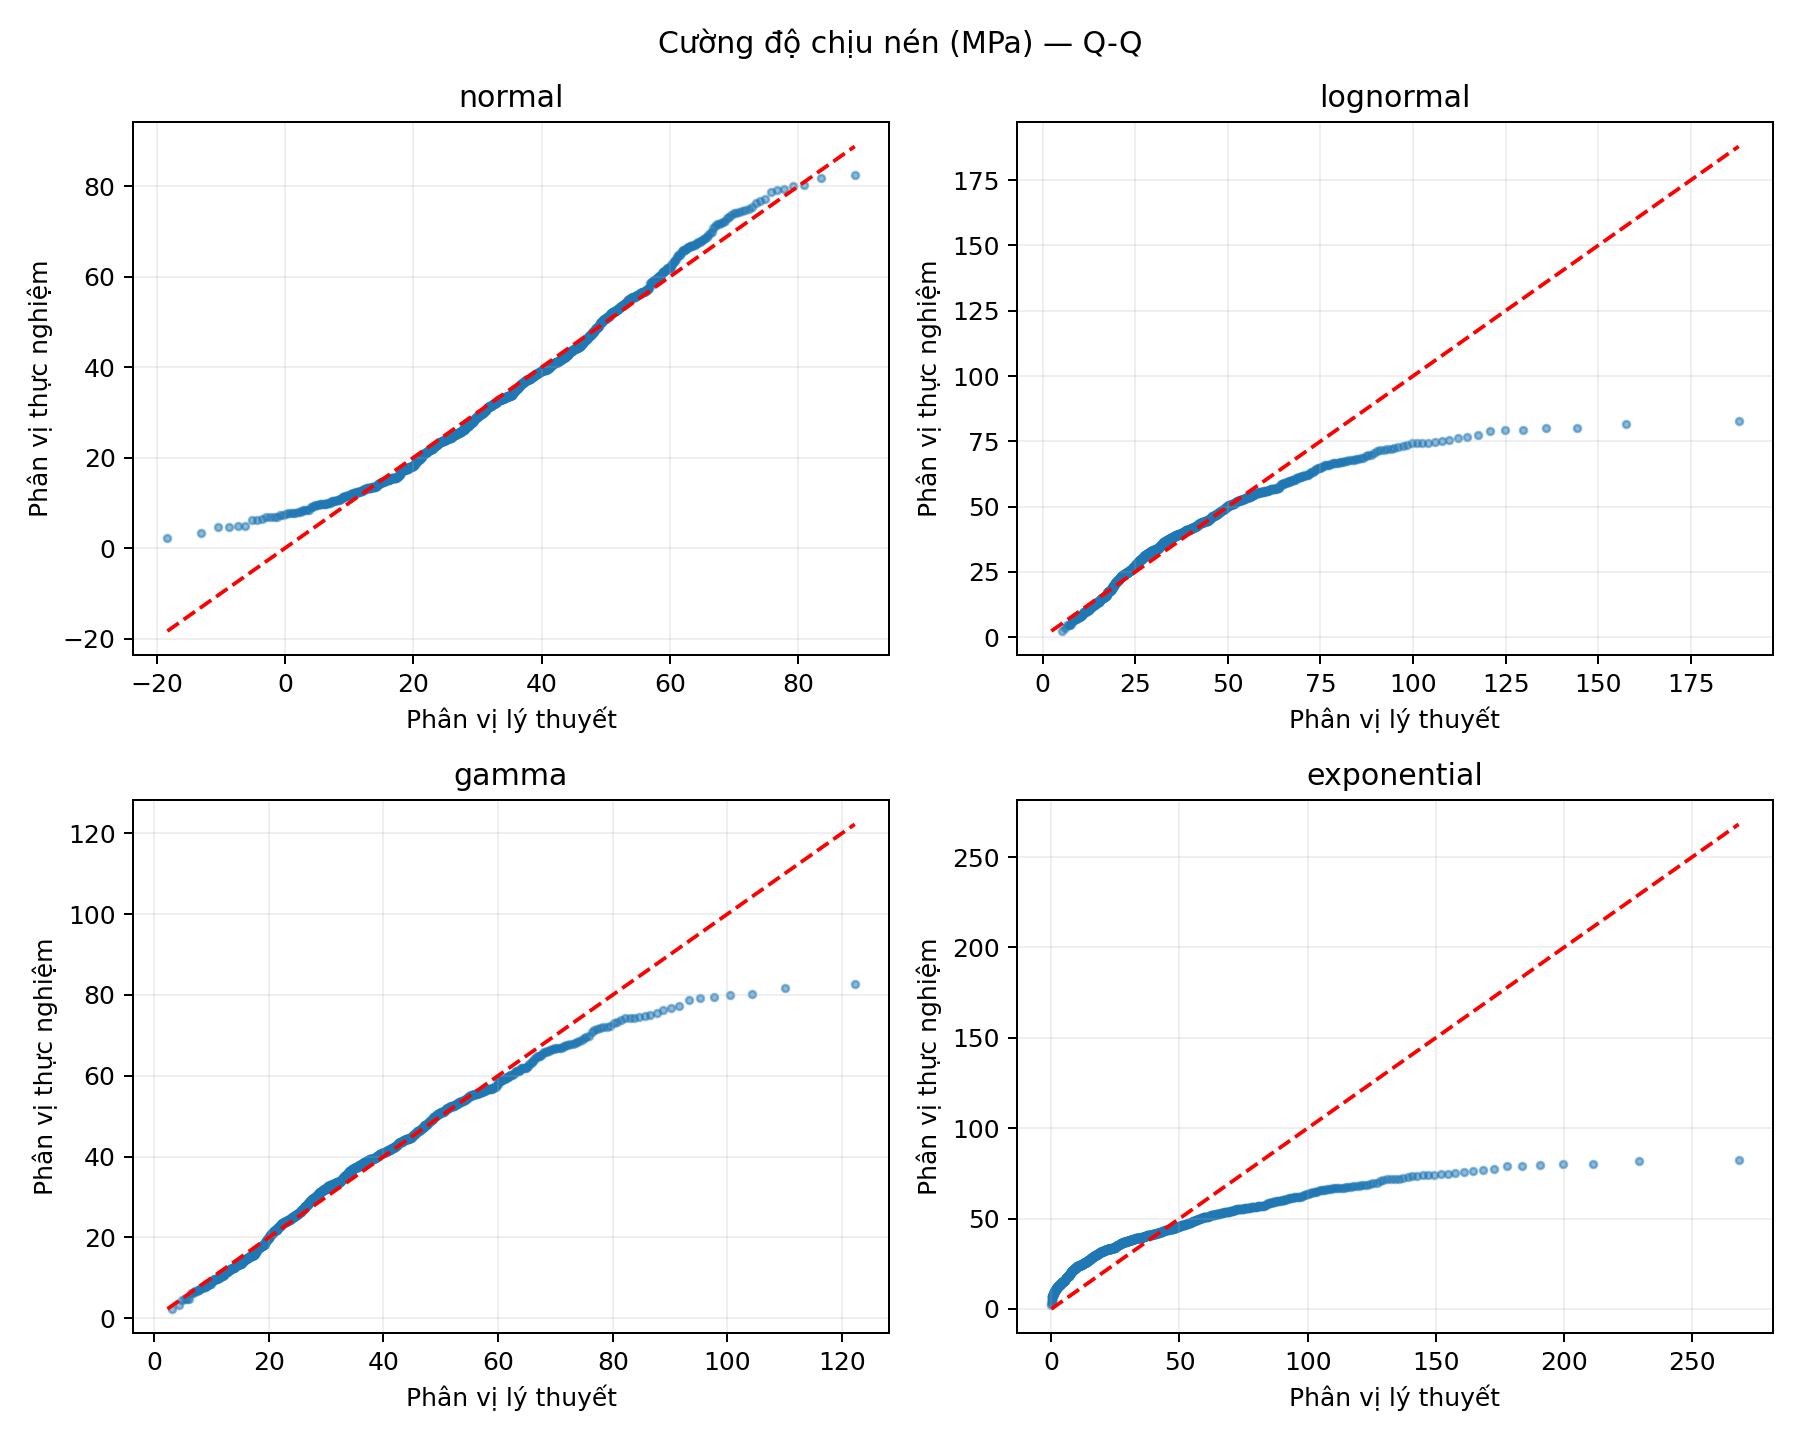

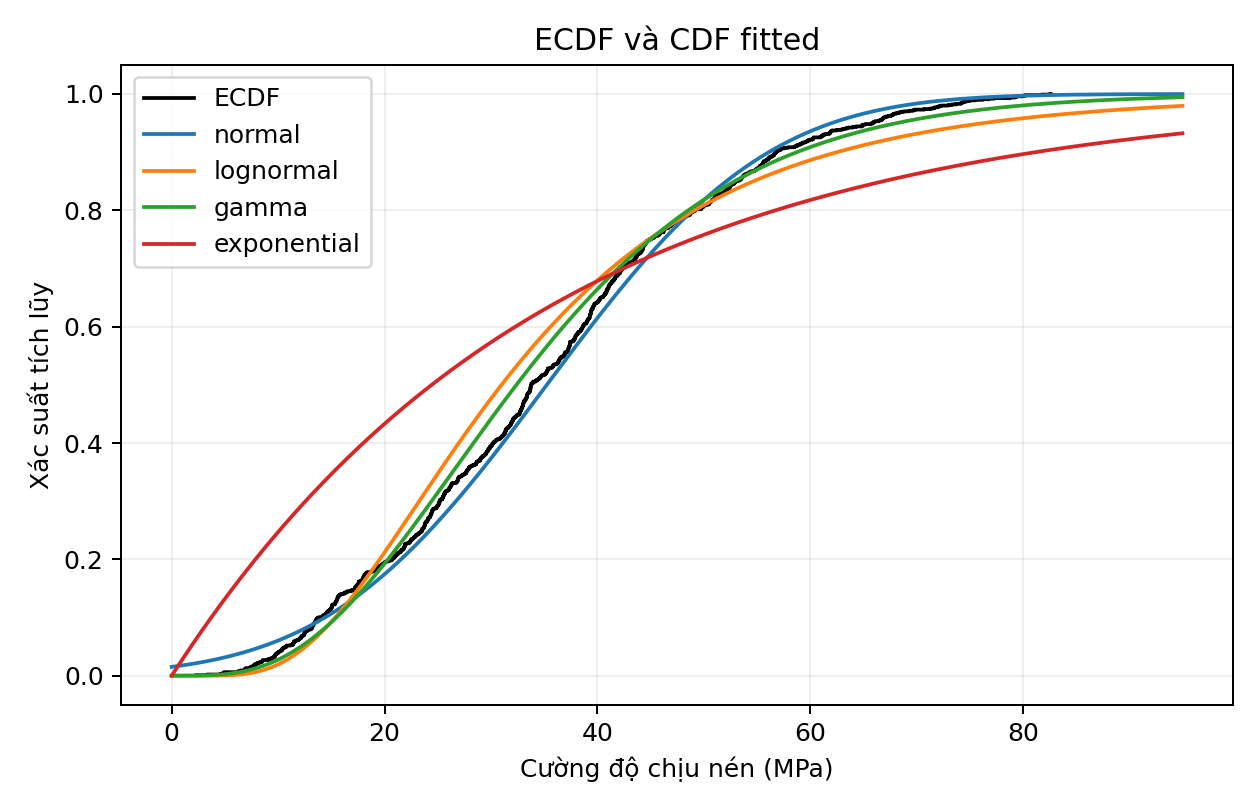



## Tỷ lệ nước/xi măng
Trung bình 0.7562, trung vị 0.6895, độ lệch chuẩn 0.3135; khoảng tứ phân vị 0.5475–0.9375, miền quan sát 0.2669–1.8824. Skewness 0.9404, excess kurtosis 0.7175. Trung bình cao hơn trung vị và skewness dương thể hiện bất đối xứng theo phía phải.

| Họ | AIC | BIC | ΔAIC | KS | p bootstrap | Kết luận ở 5% |
|---|---:|---:|---:|---:|---:|---|
| lognormal | 319.361 | 329.186 | 0.000 | 0.0403 | 0.0015 | Bác bỏ |
| gamma | 341.899 | 351.725 | 22.539 | 0.0575 | 0.0005 | Bác bỏ |
| normal | 523.710 | 533.535 | 204.349 | 0.1082 | 0.0005 | Bác bỏ |
| exponential | 1450.368 | 1455.280 | 1131.007 | 0.3398 | 0.0005 | Bác bỏ |

lognormal có AIC thấp nhất (319.361) trong bốn họ; KS = 0.0403 nghĩa là chênh lệch tích lũy lớn nhất khoảng 4.03 điểm phần trăm. Tuy nhiên, kiểm định vẫn bác bỏ họ này; đây chỉ là mô hình xấp xỉ tốt nhất trong tập ứng viên, không phải phân phối được xác nhận.
Tham số ước lượng của các mô hình:

| Họ | Tham số |
|---|---|
| lognormal | s = 0.40640; loc = 0; scale = 0.69655 |
| gamma | a = 6.24454; loc = 0; θ = 0.12110 |
| normal | μ = 0.75622; σ = 0.31337 |
| exponential | loc = 0; scale = 0.75622 |

- lognormal: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt -0.0042, 0.0070, -0.0093; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0001, 0.0036].
- gamma: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt -0.0251, 0.0267, -0.0556; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0000, 0.0018].
- normal: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt -0.1204, 0.0667, -0.0968; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0000, 0.0018].
- exponential: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt -0.3224, -0.1654, 0.8970; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [0.0000, 0.0018].

Histogram/KDE có đỉnh nổi bật quanh 0,6 và đuôi kéo dài về bên phải. Lognormal theo sát hình dạng trung tâm hơn chuẩn; thay đổi bandwidth vẫn giữ đỉnh chính nhưng làm thay đổi độ cao và các gợn nhỏ. Q-Q lognormal gần đường y=x trên phần lớn miền, lệch rõ hơn ở các phân vị cao nhất và xuất hiện đoạn ngang do giá trị lặp. Sai số tại 5%, 50%, 95% nhỏ (−0,0042; +0,0070; −0,0093), nhưng tại 99% tăng lên +0,1330. Gamma có sai số 99% nhỏ hơn (−0,0287) nhưng AIC cao hơn 22,539 và KS lớn hơn; ưu thế ở một phân vị không đồng nghĩa khớp toàn bộ phân phối tốt hơn. Chuẩn không tái hiện tính bất đối xứng; exponential giảm ngay từ gốc nên bỏ qua đỉnh thực nghiệm.
Lognormal có thể dùng để xấp xỉ vùng trung tâm của w_c, nhưng p bootstrap = 0,0015 vẫn cho thấy sai lệch có hệ thống dưới giả định kiểm định. Không diễn giải hình Q-Q gần thẳng là xác nhận lognormal chính xác.

Chuẩn gán xác suất 0.791% cho giá trị ≤0, trong khi biến có miền vật lý dương.



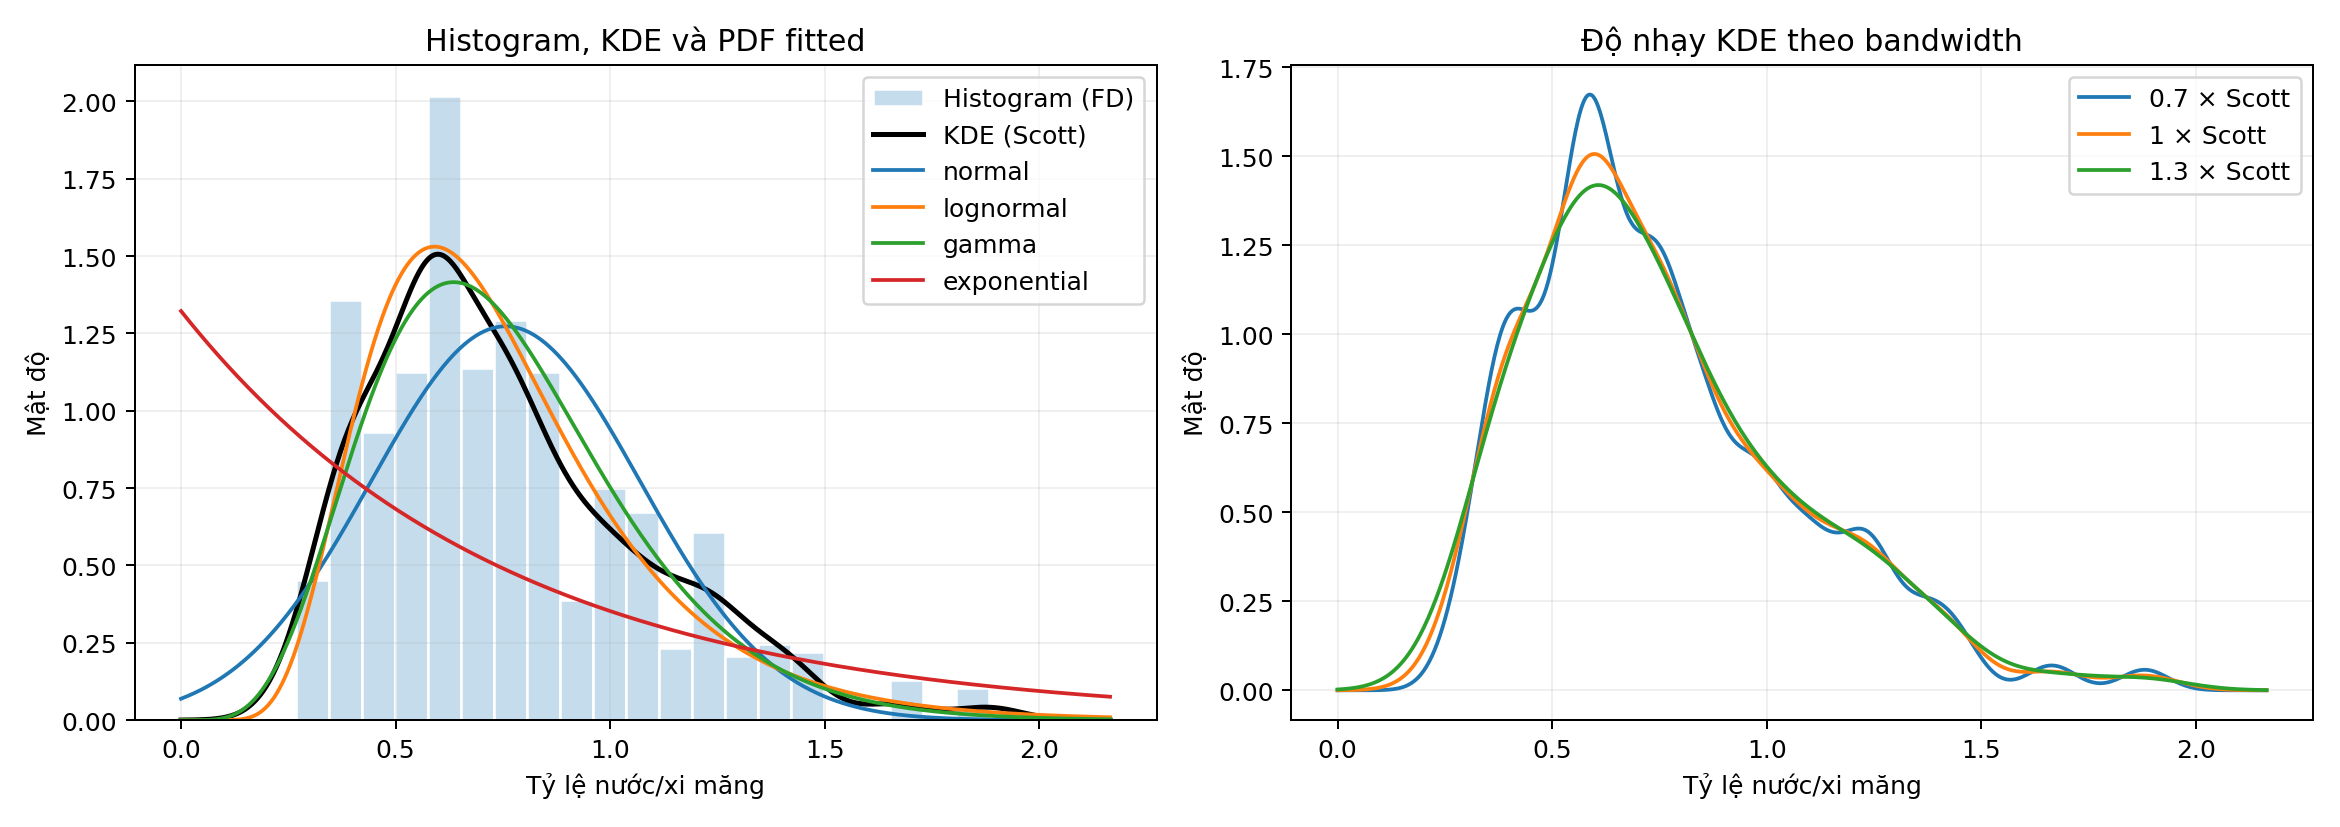

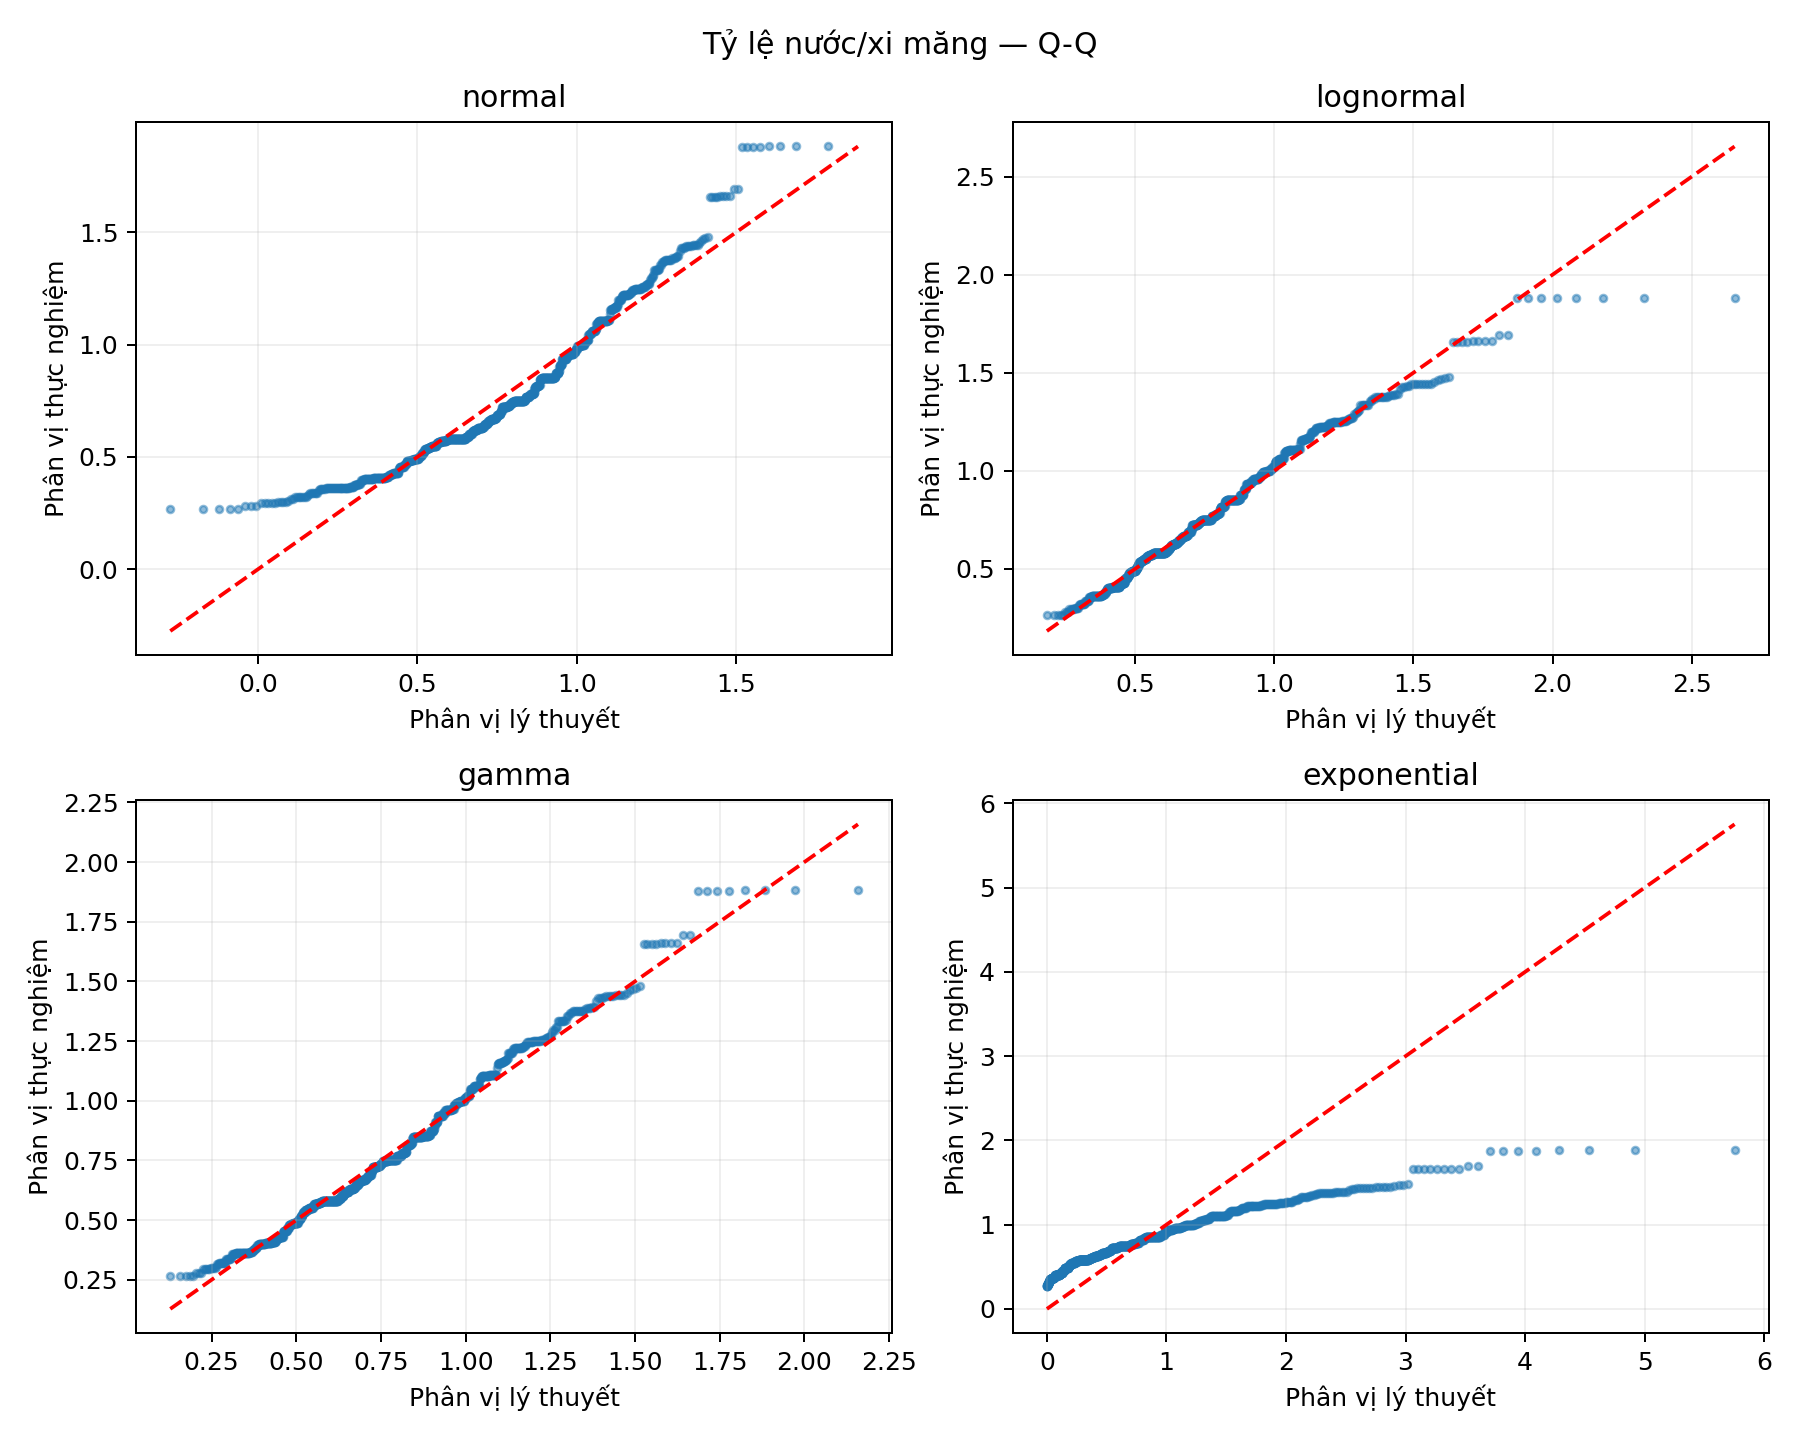

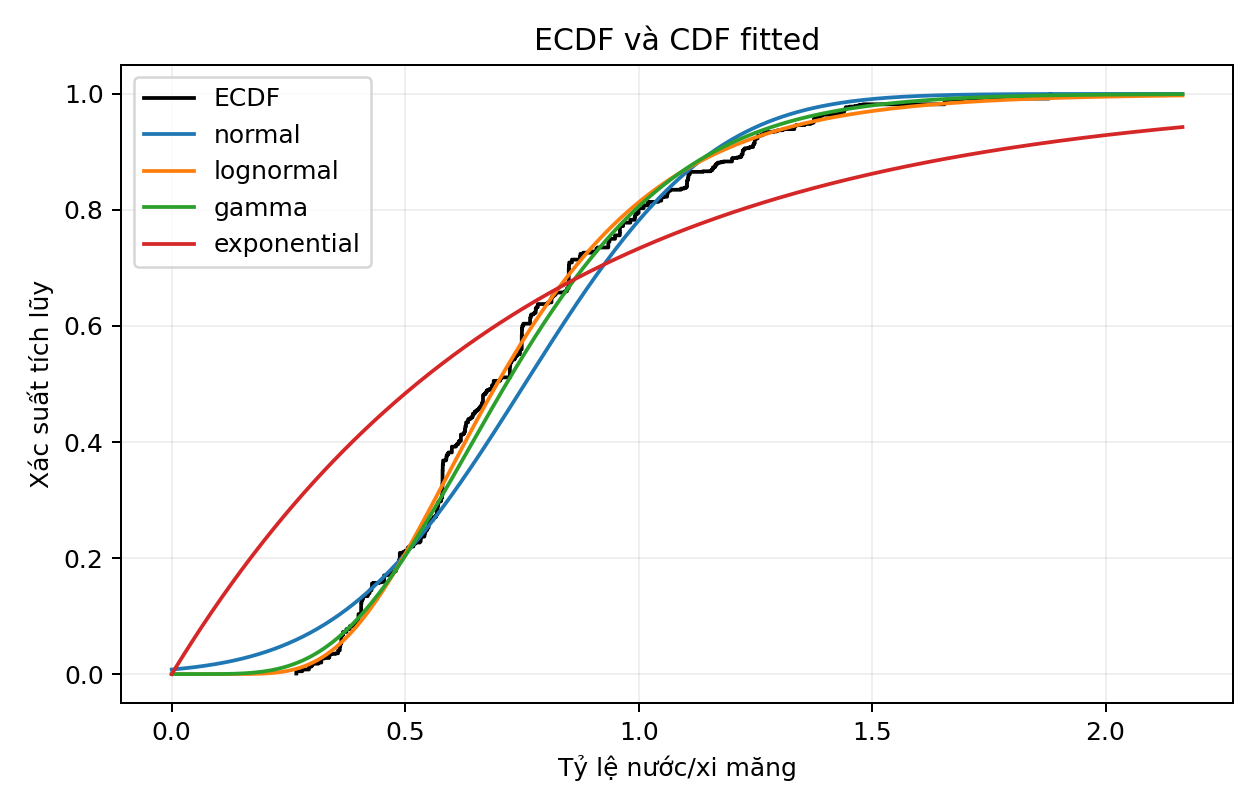



## Diễn giải và kết luận
Phân phối gộp strength phản ánh đồng thời nhiều cấp phối và giai đoạn dưỡng hộ. Trung vị theo nhóm tuổi được ghi dưới đây; khác biệt vị trí giữa các nhóm giúp giải thích độ phân tán của mẫu gộp, nhưng không tách được tác động riêng của tuổi khỏi thành phần vật liệu.

| Nhóm tuổi | n | Trung vị strength (MPa) |
|---|---:|---:|
| Dài ngày (>28 ngày) | 271 | 45.368 |
| Sớm (1–7 ngày) | 253 | 17.575 |
| Tiêu chuẩn (8–28 ngày) | 481 | 33.088 |

w_c lệch phải cho thấy phần lớn mẫu có tỷ lệ tương đối thấp hơn các giá trị lớn ở đuôi. Các mức cấp phối lặp có thể tạo đỉnh hoặc đoạn bậc trên ECDF; KDE làm trơn các cấu trúc này chứ không chứng minh tồn tại nhiều quần thể. Không suy luận rằng phân phối của strength hoặc w_c chính là phân phối sai số của một mô hình hồi quy.
Cả bốn họ phân phối đều bị bác bỏ ở mức ý nghĩa 5% đối với hai biến. Vì vậy, chưa có họ nào trong tập ứng viên mô tả đầy đủ phân phối quan sát dưới giả định kiểm định. Gamma là mô hình xấp xỉ có AIC thấp nhất cho strength, còn lognormal có AIC thấp nhất cho w_c. Mô tả thực nghiệm bằng histogram/KDE, ECDF và phân vị là căn cứ chính; các mô hình fitted hỗ trợ xấp xỉ và cần được xem xét cùng sai lệch đuôi. Các kết luận áp dụng cho bộ thí nghiệm quan sát.

## Tài liệu tham khảo
- Repository: https://github.com/vkyphong/concrete-compressive-strength-analysis; commit kiểm tra: edbdefd048cbcc7d2ec437f932e6e570625398f7.
- Quy trình dữ liệu: `notebooks/01_eda.ipynb`, `data/processed/README.md`, `report/eda_summary.md`.
- Phương pháp bootstrap fit lại: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.goodness_of_fit.html.

In [7]:
lines = ['# 2. Phân tích phân phối xác suất', '',
    '## Dữ liệu và mục tiêu',
    f'Phân tích {len(df):,} quan sát sau EDA từ `data/processed/cleaned.csv`. Giữ nguyên toàn bộ dữ liệu, kể cả các quan sát được gắn cờ ngoại lai. Chọn cường độ chịu nén strength (MPa) và tỷ lệ nước/xi măng w_c (không đơn vị). Strength là biến mục tiêu; w_c mô tả quan hệ giữa nước và xi măng trong cấp phối, không bao gồm các vật liệu bổ sung trong mẫu số.', '',
    'Strength phản ánh kết quả chịu lực; phân tích phân phối giúp xác định vùng cường độ tập trung, mức biến thiên và các giá trị ở hai đuôi. w_c được chọn vì tỷ lệ kết hợp lượng nước và lượng xi măng, cung cấp thông tin cấp phối mà lượng nước riêng lẻ chưa thể hiện đầy đủ. Hai biến đại diện cho kết quả thí nghiệm và một đặc điểm cấp phối liên quan. Việc lựa chọn dựa trên ý nghĩa phân tích, không dựa vào phân phối nào dễ khớp.', '',
    selection_text, '',
    '## Phương pháp',
    'Ước lượng MLE cho chuẩn, lognormal, gamma và exponential; ba họ dương cố định loc=0. Chuẩn, lognormal và gamma có hai tham số tự do, exponential có một. So sánh AIC/BIC trong từng biến. Kiểm định KS với bootstrap tham số 1.999 lần, ước lượng lại tham số ở mỗi lần, seed 20261009; mức ý nghĩa 0,05. p-value nhỏ nhất báo cáo được là 0,0005, không có nghĩa xác suất bằng 0. Kiểm định giả định các quan sát độc lập cùng phân phối; cấu trúc cấp phối và tuổi thí nghiệm có thể ảnh hưởng mức hiệu lực của giả định này.', '',
    'Histogram dùng mật độ và bin Freedman–Diaconis, KDE dùng Scott và kiểm tra độ nhạy bandwidth. PDF fitted, Q-Q theo đường y=x và ECDF được dùng bổ sung để đánh giá vùng trung tâm, đuôi và sai lệch tích lũy.', '']
for v, label in VARIABLES.items():
    s = summary.set_index('variable').loc[v]
    r = results[results.variable.eq(v)].sort_values('AIC')
    best = r.iloc[0]
    lines += [f'## {label}',
        f'Trung bình {s["mean"]:.4f}, trung vị {s["median"]:.4f}, độ lệch chuẩn {s["std"]:.4f}; khoảng tứ phân vị {s.q1:.4f}–{s.q3:.4f}, miền quan sát {s["min"]:.4f}–{s["max"]:.4f}. Skewness {s.skewness:.4f}, excess kurtosis {s.excess_kurtosis:.4f}. Trung bình cao hơn trung vị và skewness dương thể hiện bất đối xứng theo phía phải.', '',
        '| Họ | AIC | BIC | ΔAIC | KS | p bootstrap | Kết luận ở 5% |',
        '|---|---:|---:|---:|---:|---:|---|']
    for _, row in r.iterrows():
        lines.append(f'| {row.distribution} | {row.AIC:.3f} | {row.BIC:.3f} | {row.delta_AIC:.3f} | {row.KS:.4f} | {row.p_bootstrap:.4f} | '+('Bác bỏ' if row.reject_005 else 'Chưa bác bỏ')+' |')
    lines += ['', f'{best.distribution} có AIC thấp nhất ({best.AIC:.3f}) trong bốn họ; KS = {best.KS:.4f} nghĩa là chênh lệch tích lũy lớn nhất khoảng {best.KS*100:.2f} điểm phần trăm. '+('Tuy nhiên, kiểm định vẫn bác bỏ họ này; đây chỉ là mô hình xấp xỉ tốt nhất trong tập ứng viên, không phải phân phối được xác nhận.' if best.reject_005 else 'Kiểm định chưa bác bỏ họ này; kết quả không chứng minh dữ liệu tuân theo chính xác mô hình.'),
        'Tham số ước lượng của các mô hình:', '',
        '| Họ | Tham số |', '|---|---|']
    for _, row in r.iterrows():
        pars = json.loads(row.parameters)
        if row.distribution == 'normal': description = f'μ = {pars[0]:.5f}; σ = {pars[1]:.5f}'
        elif row.distribution == 'lognormal': description = f's = {pars[0]:.5f}; loc = 0; scale = {pars[2]:.5f}'
        elif row.distribution == 'gamma': description = f'a = {pars[0]:.5f}; loc = 0; θ = {pars[2]:.5f}'
        else: description = f'loc = 0; scale = {pars[1]:.5f}'
        lines.append(f'| {row.distribution} | {description} |')
    lines.append('')
    for _, row in r.iterrows():
        t = quantiles[(quantiles.variable==v)&(quantiles.distribution==row.distribution)].set_index('probability')
        lines.append(f'- {row.distribution}: sai số phân vị fitted − mẫu tại 5%, 50%, 95% lần lượt {t.loc[.05,"error"]:.4f}, {t.loc[.5,"error"]:.4f}, {t.loc[.95,"error"]:.4f}; khoảng tin cậy 95% cho xác suất vượt KS trong mô phỏng [{row.mc_ci_low:.4f}, {row.mc_ci_high:.4f}].')
    if v == 'strength':
        lines += ['', 'Histogram/KDE thể hiện một vùng đỉnh rộng khoảng 30–40 MPa và đuôi phải. Khi đổi bandwidth, các gợn nhỏ thay đổi nhưng hình dạng tổng thể ổn định. PDF chuẩn mô tả vùng đỉnh khá sát, trong khi gamma và lognormal đặt đỉnh về phía thấp hơn. Q-Q chuẩn gần đường tham chiếu ở vùng giữa, nhưng lệch ở đuôi trái vì chuẩn cho phép giá trị âm. Gamma khớp nhiều phân vị trung tâm nhưng dự báo đuôi trên dài hơn mẫu: tại 99%, mô hình cho 88,162 MPa so với 75,477 MPa thực nghiệm, lệch +12,684 MPa. Lognormal lệch mạnh hơn ở 99% (+35,295 MPa). Exponential không tái hiện được đỉnh bên trong miền dương và đánh giá quá cao đuôi trên.',
            'Chuẩn có KS nhỏ hơn gamma (0,0387 so với 0,0579), dù AIC cao hơn 27,442. Hai tiêu chí đo các khía cạnh khác nhau: KS xét sai lệch CDF lớn nhất, còn AIC dựa trên tổng log mật độ tại các quan sát. Do đó không gọi gamma là tốt nhất trên mọi tiêu chí.']
    else:
        lines += ['', 'Histogram/KDE có đỉnh nổi bật quanh 0,6 và đuôi kéo dài về bên phải. Lognormal theo sát hình dạng trung tâm hơn chuẩn; thay đổi bandwidth vẫn giữ đỉnh chính nhưng làm thay đổi độ cao và các gợn nhỏ. Q-Q lognormal gần đường y=x trên phần lớn miền, lệch rõ hơn ở các phân vị cao nhất và xuất hiện đoạn ngang do giá trị lặp. Sai số tại 5%, 50%, 95% nhỏ (−0,0042; +0,0070; −0,0093), nhưng tại 99% tăng lên +0,1330. Gamma có sai số 99% nhỏ hơn (−0,0287) nhưng AIC cao hơn 22,539 và KS lớn hơn; ưu thế ở một phân vị không đồng nghĩa khớp toàn bộ phân phối tốt hơn. Chuẩn không tái hiện tính bất đối xứng; exponential giảm ngay từ gốc nên bỏ qua đỉnh thực nghiệm.',
            'Lognormal có thể dùng để xấp xỉ vùng trung tâm của w_c, nhưng p bootstrap = 0,0015 vẫn cho thấy sai lệch có hệ thống dưới giả định kiểm định. Không diễn giải hình Q-Q gần thẳng là xác nhận lognormal chính xác.']
    normal = r[r.distribution.eq('normal')].iloc[0]
    lines += ['', f'Chuẩn gán xác suất {normal.negative_mass*100:.3f}% cho giá trị ≤0, trong khi biến có miền vật lý dương.', '',
        f'![Histogram, KDE và PDF của {v}](../../figures/distribution_analysis/{v}_hist_kde_pdf.png)',
        f'![Q-Q của {v}](../../figures/distribution_analysis/{v}_qq.png)',
        f'![ECDF của {v}](../../figures/distribution_analysis/{v}_ecdf.png)', '']
lines += ['## Diễn giải và kết luận',
    'Phân phối gộp strength phản ánh đồng thời nhiều cấp phối và giai đoạn dưỡng hộ. Trung vị theo nhóm tuổi được ghi dưới đây; khác biệt vị trí giữa các nhóm giúp giải thích độ phân tán của mẫu gộp, nhưng không tách được tác động riêng của tuổi khỏi thành phần vật liệu.', '',
    '| Nhóm tuổi | n | Trung vị strength (MPa) |', '|---|---:|---:|']
for group, row in groups.iterrows(): lines.append(f'| {group} | {int(row["count"])} | {row["median"]:.3f} |')
lines += ['', 'w_c lệch phải cho thấy phần lớn mẫu có tỷ lệ tương đối thấp hơn các giá trị lớn ở đuôi. Các mức cấp phối lặp có thể tạo đỉnh hoặc đoạn bậc trên ECDF; KDE làm trơn các cấu trúc này chứ không chứng minh tồn tại nhiều quần thể. Không suy luận rằng phân phối của strength hoặc w_c chính là phân phối sai số của một mô hình hồi quy.',
    'Cả bốn họ phân phối đều bị bác bỏ ở mức ý nghĩa 5% đối với hai biến. Vì vậy, chưa có họ nào trong tập ứng viên mô tả đầy đủ phân phối quan sát dưới giả định kiểm định. Gamma là mô hình xấp xỉ có AIC thấp nhất cho strength, còn lognormal có AIC thấp nhất cho w_c. Mô tả thực nghiệm bằng histogram/KDE, ECDF và phân vị là căn cứ chính; các mô hình fitted hỗ trợ xấp xỉ và cần được xem xét cùng sai lệch đuôi. Các kết luận áp dụng cho bộ thí nghiệm quan sát.', '',
    '## Tài liệu tham khảo',
    '- Repository: https://github.com/vkyphong/concrete-compressive-strength-analysis; commit kiểm tra: edbdefd048cbcc7d2ec437f932e6e570625398f7.',
    '- Quy trình dữ liệu: `notebooks/01_eda.ipynb`, `data/processed/README.md`, `report/eda_summary.md`.',
    '- Phương pháp bootstrap fit lại: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.goodness_of_fit.html.']
report_text = '\n'.join(lines)
# Hiển thị hình dưới dạng đầu ra nhúng để notebook không phụ thuộc đường dẫn ảnh.
import re
from IPython.display import Image
cursor = 0
for match in re.finditer(r'!\[([^\]]*)\]\(([^)]+)\)', report_text):
    display(Markdown(report_text[cursor:match.start()]))
    image_path = (REPORT / match.group(2)).resolve()
    display(Image(data=image_path.read_bytes(), format='png'))
    cursor = match.end()
display(Markdown(report_text[cursor:]))
assert hashlib.sha256(DATA.read_bytes()).hexdigest() == HASH
assert len(results) == 8 and len(list(FIG.glob('*.png'))) == 6
